In [1]:
RUNNING_IN_COLAB = False

In [2]:
if RUNNING_IN_COLAB:
    # Colab bootstrap: clone repo and cd into it. Skipped if already present (local Jupyter).
    import os
    if not os.path.exists('HartyMaze_ReinforcementLearning'):
        !git clone https://github.com/IrvingGomez/HartyMaze_ReinforcementLearning.git
        %cd HartyMaze_ReinforcementLearning
    os.makedirs('outputs', exist_ok=True)

# Harty and the Treasure Maze

Welcome! Harty wants to find a treasure hidden inside a maze.
We will teach Harty the best plan (a *policy*) for getting to the treasure
no matter which cell he starts in.

The technique is called **Iterative Policy Improvement**. The idea:

1. Start with a random plan.
2. Score it: how good is every cell under this plan?
3. Improve the plan: at each cell, pick the action that leads to the best score.
4. Repeat until the plan stops changing.

Run every cell from top to bottom (Shift + Enter).


In [1]:
import sys
from pathlib import Path

# Make modules in src/ importable from this notebook.
sys.path.insert(0, str(Path.cwd() / 'src'))

import numpy as np
import matplotlib.pyplot as plt

from environment import SMALL_MAZE, BIG_MAZE, validate_setup
from policy_iteration import policy_iteration, uniform_random_policy_value
from visualization import plot_policy_and_value, plot_value_only
from animation import animate_path, save_animation, simulate_path, uniform_random_action
from IPython.display import HTML, Image

## 1. How the maze is encoded

Every cell in the maze is given a number from **0 to 15**. The number tells
which walls that cell has. Here is the legend:

<img src="images/MouseMazeCode.png" width="600">

Code **15** is special: it means all four walls. We use it for **rocks**
(impassable cells where Harty cannot stand). Rocks have no value and no
policy arrow.

## 2. Choose your setup

Change the values below to play with the maze. Then rerun every cell.

- `MAZE` is a numpy array of wall codes (default supplied by the project).
- `TREASURE` is the (row, column) where the treasure sits.
- `HARTY` is the cell where Harty stands.
- `DISCOUNT_RATE` (gamma) decides how much Harty cares about future steps.
  Closer to 1 = patient; closer to 0 = short-sighted.
- `HOLES` is a list of cells that end the game with reward -1. Leave empty
  for none.
- `PORTALS` is a list of pairs of cells. Each pair teleports Harty between
  its two endpoints (either way). Up to two pairs are supported; leave the
  list empty for none.


In [ ]:
DISCOUNT_RATE = 0.9

# The environment already includes two mazes (SMALL_MAZE and BIG_MAZE)
GAME = 3 # 0 for maze in slides, 1 for SMALL_MAZE, 2 for BIG_MAZE, 3 for customized maze

if GAME==0:
    MAZE = np.array([
        [0,1,1,2],
        [14,15,3,5],
        [6,7,7,8]
    ])
    TREASURE = (0, 3)
    HARTY = (2, 0)
    HOLES = [(1,3)]
    PORTALS = []
elif GAME==1:
    MAZE = SMALL_MAZE
    TREASURE = (0,4)
    HARTY = (1,1)
    HOLES = []
    PORTALS = []
elif GAME==2:
    MAZE = BIG_MAZE
    TREASURE = (0, 15)
    HARTY = (11, 12)
    HOLES = [
        (2,14),
        (14,16)
    ]              
    PORTALS = [
        ((3,0),(14,12)),
        ((8,16),(12,17))
    ]
elif GAME ==3:
    MAZE = np.array([
        [],
        [],
        [],
        [],
        []
    ])
    TREASURE = ()
    HARTY = ()
    HOLES = [
        (),
        (),
        ()
    ]
    PORTALS = [
        ((),()),
        ((),())
    ]

validate_setup(MAZE, TREASURE, HARTY, HOLES, PORTALS)

rows, cols = MAZE.shape
print(f'Maze: {rows} x {cols}')
print(f'Treasure at {TREASURE}, Harty at {HARTY}, gamma = {DISCOUNT_RATE}')
print(f'Holes: {HOLES}')
print(f'Portals: {PORTALS}')

Maze: 5 x 5
Treasure at (4, 4), Harty at (0, 0), gamma = 0.9
Holes: [(1, 3), (3, 2), (4, 2)]
Portals: [((0, 4), (4, 0)), ((1, 4), (3, 4))]


## 3. The maze

Here is the empty maze with the treasure and Harty placed at the cells you
chose. No learning yet, just the picture.


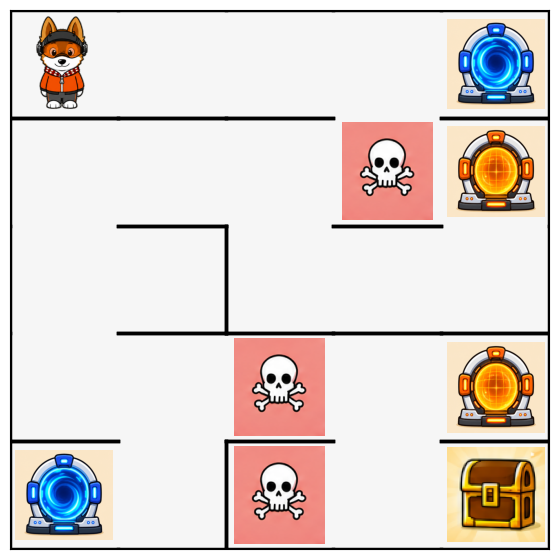

In [ ]:
V_empty = np.zeros_like(MAZE, dtype=float)
fig, _ = plot_value_only(
    V_empty, TREASURE, HARTY, MAZE,
    holes=HOLES, portals=PORTALS,
)
plt.show()

## 4. Before learning -- the random walker

To start, let us see what happens if Harty walks **randomly** at every step
(each direction with probability 1/4). The colors below show the *value* of
each cell -- how often a random walk starting there ends at the treasure.

- purple = high value
- red = low value.

You will see that random walking is bad.


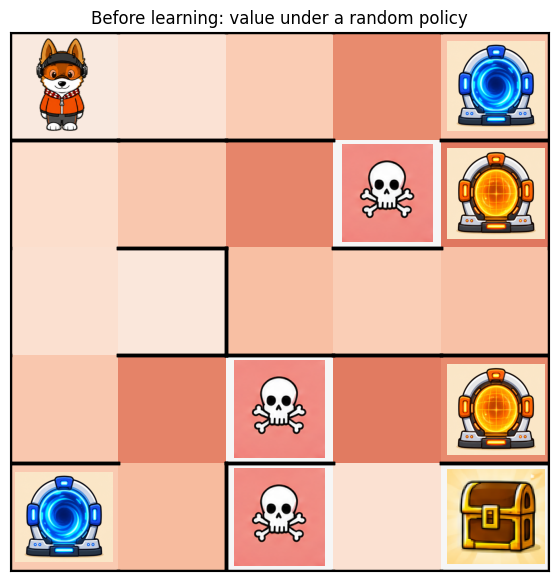

In [14]:
V_random = uniform_random_policy_value(
    TREASURE, DISCOUNT_RATE, MAZE,
    holes=HOLES, portals=PORTALS,
)

fig, _ = plot_value_only(
    V_random, TREASURE, HARTY, MAZE,
    holes=HOLES, portals=PORTALS,
    title='Before learning: value under a random policy',
)
plt.show()

### Watch Harty wander randomly

Each step Harty picks a direction at random with equal chance. You will
see him bump into walls, backtrack, and rarely reach the chest in time.


In [ ]:
random_path = simulate_path(
    uniform_random_action, HARTY, TREASURE, MAZE,
    max_steps=80, seed=0,
    holes=HOLES, portals=PORTALS,
)
anim_random = animate_path(
    random_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    value=V_random,
    title='Harty wandering (how the computer sees it)',
)

save_animation(anim_random, 'outputs/harty_random.gif', fps=2.5)

WindowsPath('outputs/harty_random.gif')

Same random walk, but without the value colors or any arrows.


In [ ]:
anim_random_plain = animate_path(
    random_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    title='Harty wandering (how we see it)',
)

save_animation(anim_random_plain, 'outputs/harty_random_plain.gif', fps=2.5)

WindowsPath('outputs/harty_random_plain.gif')

## 5. After learning -- the best policy

Now we run **Iterative Policy Improvement**. Each cell gets an arrow telling
Harty the best direction to go from there. The colors show how good each
cell is under this learned plan.

If you follow the arrows starting from Harty's cell, you should reach the
treasure.


Policy iteration converged in 16 cycles.


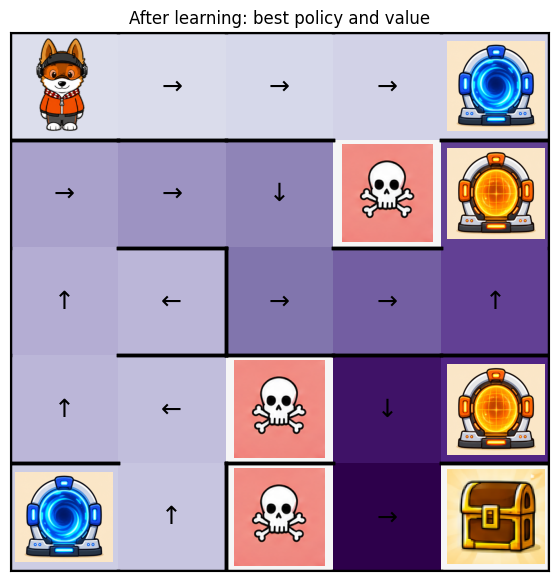

In [17]:
policy, V, cycles = policy_iteration(
    TREASURE, DISCOUNT_RATE, MAZE, seed=0,
    holes=HOLES, portals=PORTALS,
    n_eval_sweeps=200,
    max_cycles=100,
    tol=1e-3
)
print(f'Policy iteration converged in {cycles} cycles.')

fig, _ = plot_policy_and_value(
    policy, V, TREASURE, HARTY, MAZE,
    holes=HOLES, portals=PORTALS,
    title='After learning: best policy and value',
)
plt.show()

### Watch Harty follow the best policy

Now Harty obeys the arrows at every cell. He should walk straight to the
treasure with no backtracking.


In [ ]:
best_path = simulate_path(
    policy, HARTY, TREASURE, MAZE, max_steps=200,
    holes=HOLES, portals=PORTALS,
)
anim_best = animate_path(
    best_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    value=V,
    policy=policy,
    title='Harty following the best policy (how the computer sees it)',
)

save_animation(anim_best, 'outputs/harty_best.gif', fps=2.5)

WindowsPath('outputs/harty_best.gif')

Same optimal walk, but without value colors or arrows. Pure focus on the path Harty takes to reach the treasure.


In [ ]:
anim_best_plain = animate_path(
    best_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    title='Harty following the best policy (how we see it)',
)

save_animation(anim_best_plain, 'outputs/harty_best_plain.gif', fps=2.5)

WindowsPath('outputs/harty_best_plain.gif')

Watch that it doesn't matter where Harty starts. Change the initial point of Harty, and you will see how he still reaches the chest.


In [ ]:
HARTY = (2,1)
validate_setup(MAZE, TREASURE, HARTY, HOLES, PORTALS)

best_path = simulate_path(
    policy, HARTY, TREASURE, MAZE, max_steps=200,
    holes=HOLES, portals=PORTALS,
)
anim_best_plain = animate_path(
    best_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    title='Harty following the best policy (how we see it)',
)

save_animation(anim_best_plain, 'outputs/harty_best_plain_2.gif', fps=2.5)

WindowsPath('outputs/harty_best_plain_2.gif')

## What to try next

- Move the treasure to a different cell (for example `(5, 5)`).
- Move Harty.
- Change `DISCOUNT_RATE` to `0.5` (impatient) or `0.99` (very patient).
- Build your own maze with the wall codes from section 1.

Rerun the notebook each time. The plan and the colors will update.
